<a href="https://colab.research.google.com/github/ArjunJSaini14/ArjunJSaini14/blob/main/machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

              Method  Training MSE  Training R2  Test MSE  Test R2  \
0  Linear Regression      0.240485     0.047436  0.263354 -0.01329   

   Training Accuracy  Test Accuracy  
0            0.61125           0.56  
          Method  Training MSE  Training R2  Test MSE   Test R2  \
0  Random Forest        0.2132     0.155514  0.237199  0.087345   

   Training Accuracy  Test Accuracy  
0              0.725          0.665  


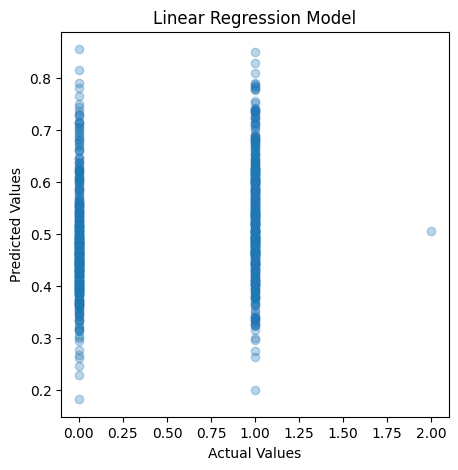

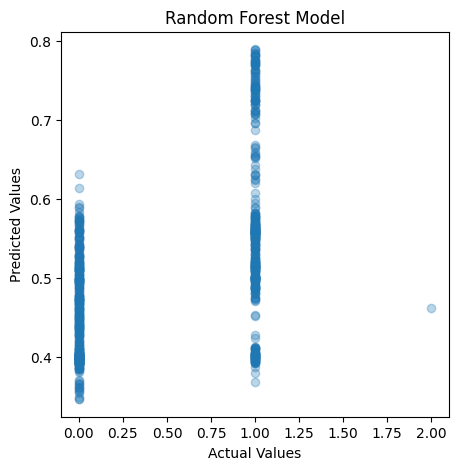

In [ ]:
# Metabolic Syndrome Project

import pandas as pd  # Data manipulation library
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting library
from sklearn.model_selection import train_test_split  # Split data into train/test sets
from sklearn.linear_model import LinearRegression  # Linear regression model
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Model evaluation metrics
from sklearn.ensemble import RandomForestRegressor  # Random forest model
from sklearn.preprocessing import LabelEncoder  # Convert categorical labels to numbers
from sklearn.impute import SimpleImputer  # Fill in missing values

# Load Data
url = 'https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/metabolic_syndrome_synthetic_data.csv'
df = pd.read_csv(url)

# Handle Missing Values
imputer = SimpleImputer(strategy='mean')
x = df.drop('sex', axis=1)
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

# Encode Target Variable
le = LabelEncoder()
y = le.fit_transform(df['sex'])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

# Train Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

# Evaluate Model
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

# Calculate Accuracy
y_lr_train_class = np.round(y_lr_train_pred)
y_lr_test_class = np.round(y_lr_test_pred)
lr_train_acc = accuracy_score(y_train, y_lr_train_class)
lr_test_acc = accuracy_score(y_test, y_lr_test_class)

# Get Linear Regression Results
lr_results = pd.DataFrame([['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2, lr_train_acc, lr_test_acc]],
                          columns=['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2', 'Training Accuracy', 'Test Accuracy'])

# Train Random Forest Regressor
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Evaluate Model
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

# Calculate Accuracy Of Random Forest
y_rf_train_class = np.round(y_rf_train_pred)
y_rf_test_class = np.round(y_rf_test_pred)
rf_train_acc = accuracy_score(y_train, y_rf_train_class)
rf_test_acc = accuracy_score(y_test, y_rf_test_class)

rf_results = pd.DataFrame([['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2, rf_train_acc, rf_test_acc]],
                          columns=['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2', 'Training Accuracy', 'Test Accuracy'])

# Display results
print(lr_results)
print(rf_results)

# Plot Linear Regression Predictions
plt.figure(figsize=(5, 5))
plt.scatter(y_train, y_lr_train_pred, alpha=0.3)
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.title('Linear Regression Model')
plt.show()

# Display plot
plt.figure(figsize=(5, 5))
plt.scatter(y_train, y_rf_train_pred, alpha=0.3)
plt.ylabel('Predicted Values')
plt.xlabel('Actual Values')
plt.title('Random Forest Model')
plt.show()